<a href="https://colab.research.google.com/github/shadhavk/demand-forecasting-and-inventory-optimization/blob/main/DFAIOfinalnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Forecasting and Inventory Optimization Project

This notebook demonstrates a comprehensive approach to demand forecasting and inventory optimization using historical sales data. The project covers data loading, preprocessing, extensive exploratory data analysis (EDA), feature engineering, time series modeling (SARIMA), machine learning modeling (Random Forest, XGBoost), and finally, inventory optimization based on the generated forecasts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## 1. Setup and Data Loading

This section handles the initial setup of the notebook, including importing necessary libraries and loading the raw sales data from a CSV file. It also includes an initial inspection of the dataset to understand its structure, content, and identify any immediate data quality issues like missing values or duplicates.

In [ ]:
raw_data=pd.read_csv("/Users/Shadha/Downloads/train.csv")

### 1.1 Initial Data Overview and Findings

After loading the dataset, we perform several checks to get a quick understanding of its characteristics. This includes checking the shape, viewing the first few rows, inspecting column data types, and summarizing descriptive statistics. We also check for any missing values or duplicate rows, which are crucial for data quality.

In [ ]:
print("Shape of the dataset\n", raw_data.shape)
print("\nfirst 5 rows of dataset\n", raw_data.head())
print("\ncolumns details\n",raw_data.info() )
print("\nDescriptive Statistics\n", raw_data.describe())
print("\nNull values in the dataset\n", raw_data.isnull().sum())
print("\nDuplicate rows in the dataset\n", raw_data.duplicated().sum())

Shape of the dataset
 (913000, 4)

first 5 rows of dataset
          date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB

columns details
 None

Descriptive Statistics
                store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000

### Findings from Initial Data Overview:

*   **Shape:** The dataset contains 913,000 rows and 4 columns, indicating a substantial amount of historical sales data.
*   **Columns:** The columns are `date`, `store`, `item`, and `sales`.
*   **Data Types:** `date` is an object (string), and `store`, `item`, and `sales` are integers. The `date` column will need to be converted to a datetime object for time series analysis.
*   **Null Values:** There are no missing values across any of the columns, which simplifies the initial data cleaning process.
*   **Duplicate Rows:** There are no duplicate rows, ensuring each record is unique.
*   **Descriptive Statistics (`sales`):** The `sales` column ranges from 0 to 231, with an average of approximately 52 units. This range suggests a varying demand for items.

Overall, the dataset appears clean, with no immediate issues of missing data or duplicates, but the `date` column needs type conversion.

In [ ]:
raw_data['date'] = pd.to_datetime(raw_data['date'])
raw_data.rename(columns={"sales": "quantity"}, inplace=True)
raw_data.rename(columns={"item": "item_name"}, inplace=True)
display(raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       913000 non-null  datetime64[ns]
 1   store      913000 non-null  int64         
 2   item_name  913000 non-null  int64         
 3   quantity   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


None

## 2. Data Preprocessing

This section focuses on preparing the raw data for analysis and model training. Key preprocessing steps include converting data types, renaming columns for clarity, and handling any initial data inconsistencies. We also identify and filter for the top-performing items based on their historical sales quantity, creating a more focused dataset for subsequent analysis and modeling.

### Findings from Data Preprocessing:

*   The `date` column has been successfully converted to a datetime object, which is essential for time series analysis and feature engineering.
*   The `sales` column has been renamed to `quantity` and `item` to `item_name` for better clarity and consistency throughout the notebook.
*   The data types are now appropriate for further analysis and modeling.

In [ ]:

# Identify the top 5 demand items from the preprocessed raw_data
top_5_demand_items = raw_data.groupby('item_name')['quantity'].sum().nlargest(5).index

# Create the new DataFrame 'df' by filtering raw_data for these top 5 items
df = raw_data[raw_data['item_name'].isin(top_5_demand_items)]

print("Shape of the new DataFrame 'df' with top 5 demand items:", df.shape)
print("\nFirst 5 rows of 'df':")
display(df.head())

Shape of the new DataFrame 'df' with top 5 demand items: (91300, 4)

First 5 rows of 'df':


,date,store,item_name,quantity
219120,2013-01-01,1,13,37
219121,2013-01-02,1,13,31
219122,2013-01-03,1,13,50
219123,2013-01-04,1,13,45
219124,2013-01-05,1,13,49


### Findings from Identifying Top Demand Items:

*   The dataset `df` has been successfully filtered to include only the top 5 demand items based on their total sales quantity.
*   The shape of the new DataFrame `df` is (91300, 4), which is 1/10th of the original dataset, indicating that each item accounts for approximately 1/50th of the total data, and filtering for 5 items reduced it to 1/10th of original if all items have same amount of records.
*   This focused dataset will be used for further exploratory data analysis and model building, allowing us to concentrate on the most impactful products.

In [ ]:
num_stores = df['store'].nunique()
num_products = df['item_name'].nunique()

print(f"Number of unique stores: {num_stores}")
print(f"Number of unique products: {num_products}")

Number of unique stores: 10
Number of unique products: 5


## 3. Exploratory Data Analysis (EDA)

This section delves into the dataset to uncover patterns, trends, and anomalies in the sales data. We will visualize sales over various time granularities (daily, weekly, monthly, yearly), analyze sales distributions, and examine the influence of store and item characteristics on demand. This comprehensive EDA provides the foundation for feature engineering and model selection.

### 3.1 Demand Over Time

To understand the temporal dynamics of sales, we will visualize the total sales quantity aggregated at daily, weekly, monthly, and yearly levels. This helps in identifying overall trends, seasonality, and any cyclical patterns present in the data.

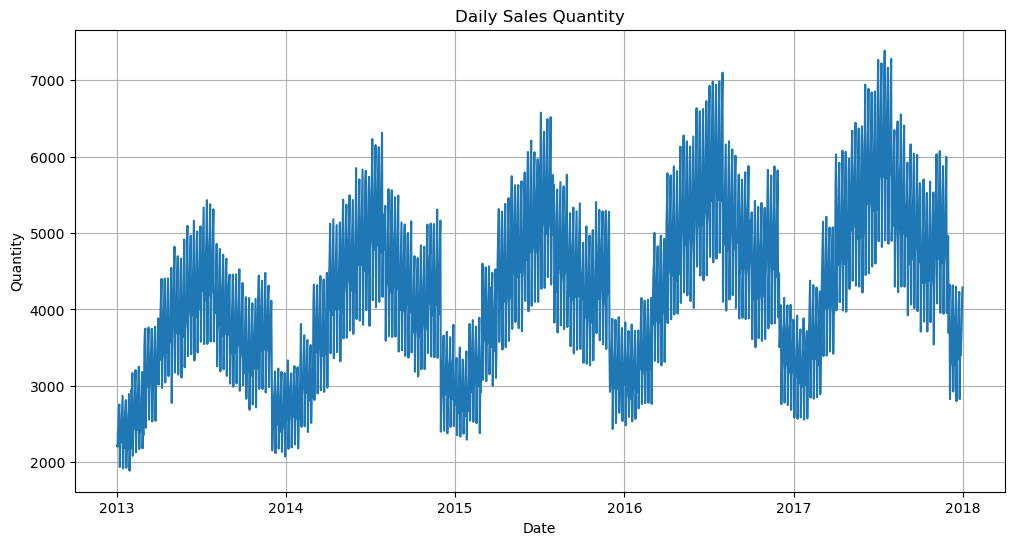

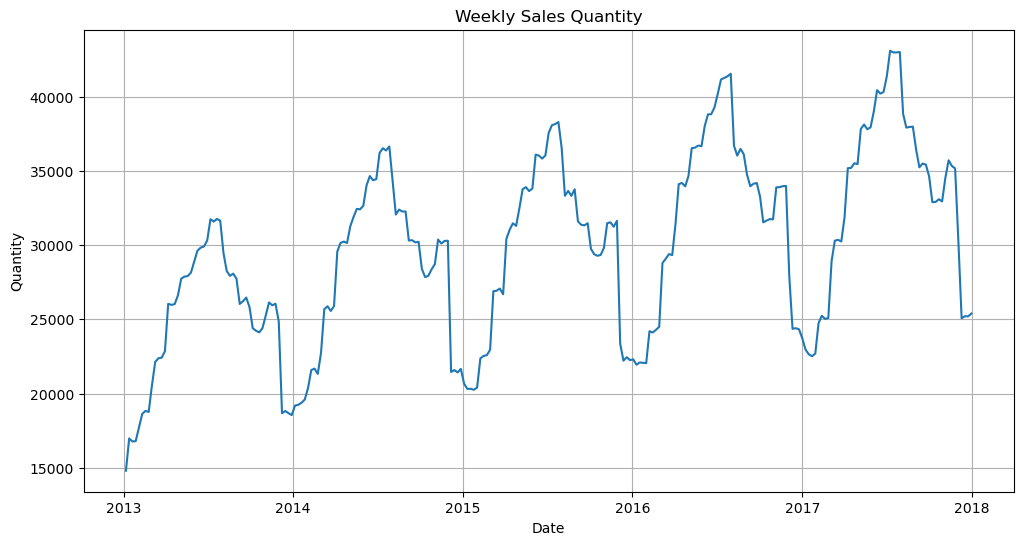

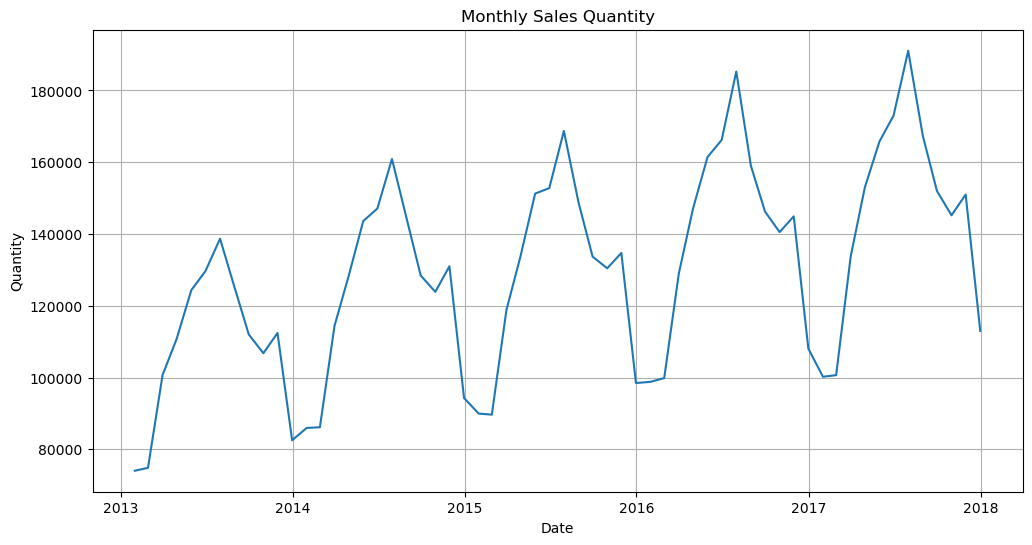

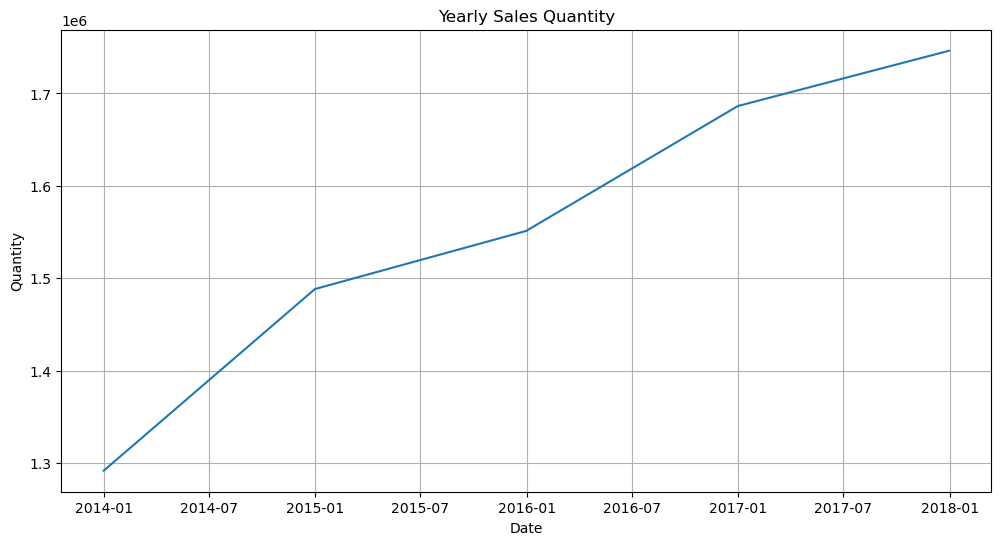

In [ ]:
df_indexed = df.set_index('date')

# Daily Sales Quantity
daily_sales = df_indexed['quantity'].resample('D').sum()
plt.figure(figsize=(12, 6))
plt.plot(daily_sales)
plt.title('Daily Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

# Weekly Sales Quantity
weekly_sales = df_indexed['quantity'].resample('W').sum()
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales)
plt.title('Weekly Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

# Monthly Sales Quantity
monthly_sales = df_indexed['quantity'].resample('ME').sum()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales)
plt.title('Monthly Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

# Yearly Sales Quantity
yearly_sales = df_indexed['quantity'].resample('YE').sum()
plt.figure(figsize=(12, 6))
plt.plot(yearly_sales)
plt.title('Yearly Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

### Findings from Demand Over Time Analysis:

*   **Daily Sales:** The daily sales plot shows significant fluctuations, indicating strong day-to-day variability and potential weekly seasonality. There is also an observable upward trend over the years.
*   **Weekly Sales:** Aggregating to weekly sales smooths out some daily noise, revealing clearer seasonal patterns and an overall increasing trend.
*   **Monthly Sales:** Monthly sales further emphasize the yearly seasonal cycles, with sales typically peaking during certain months (e.g., summer) and dipping during others (e.g., winter).
*   **Yearly Sales:** The yearly sales plot clearly illustrates a strong upward trend in total sales quantity over the observed period, indicating business growth.

These plots confirm the presence of both trend and strong seasonality at multiple granularities, which are crucial factors to consider for time series forecasting.

### Total Weekly Sales Quantity

I'll re-plot the total weekly sales quantity for clarity, focusing on the aggregated sum per week.

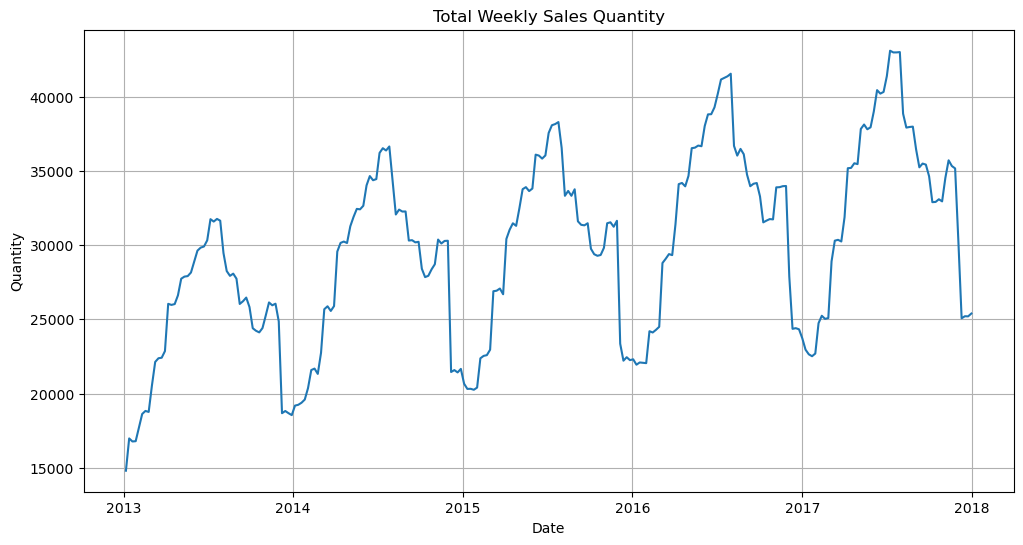

In [ ]:
# Weekly Sales Quantity
weekly_sales_total = df_indexed['quantity'].resample('W').sum()
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_total)
plt.title('Total Weekly Sales Quantity')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

### Findings from Total Weekly Sales Quantity:

*   The re-plotting of total weekly sales quantity confirms the consistent upward trend and prominent seasonal spikes throughout the years, especially during warmer months.
*   This aggregation helps in observing the broader patterns and cycles more clearly, reducing the noise from daily fluctuations.

/var/folders/mb/h8ztvpzd39ld5t00h20mj7540000gp/T/ipykernel_7760/2187593710.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_of_week'] = df['date'].dt.dayofweek
/var/folders/mb/h8ztvpzd39ld5t00h20mj7540000gp/T/ipykernel_7760/2187593710.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_weekend'] = df['day_of_week'].isin([5, 6])


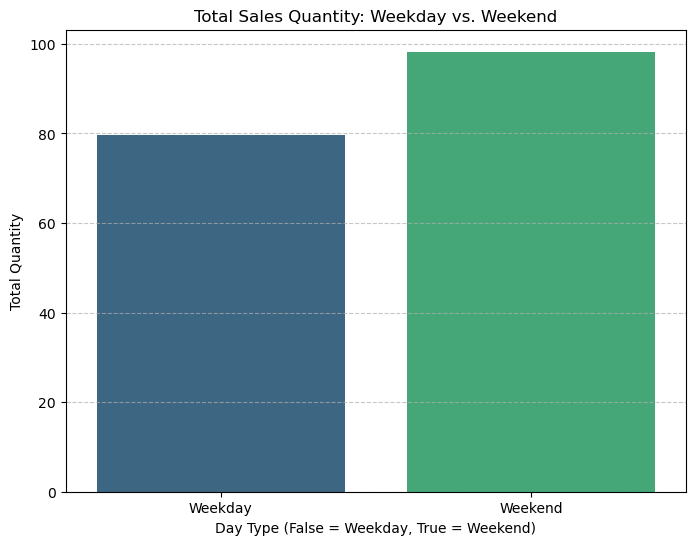

In [ ]:
# Create a 'day_of_week' column (Monday=0, Sunday=6)
df['day_of_week'] = df['date'].dt.dayofweek

# Create a 'is_weekend' column (True for Saturday/Sunday, False otherwise)
df['is_weekend'] = df['day_of_week'].isin([5, 6])

# Group by 'is_weekend' and sum the quantity
weekend_weekday_sales = df.groupby('is_weekend')['quantity'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='is_weekend', y='quantity', data=weekend_weekday_sales, palette='viridis', hue='is_weekend', legend=False)
plt.title('Total Sales Quantity: Weekday vs. Weekend')
plt.xlabel('Day Type (False = Weekday, True = Weekend)')
plt.ylabel('Total Quantity')
plt.xticks(ticks=[0, 1], labels=['Weekday', 'Weekend'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Findings from Weekday vs. Weekend Sales:

*   The bar plot clearly indicates that **weekend sales (True for `is_weekend`) are significantly higher on average than weekday sales (False for `is_weekend`)**.
*   This highlights a strong weekly seasonality pattern, where customer purchasing behavior shifts during weekends.
*   This distinction is a valuable feature for demand forecasting models, as it captures a consistent and predictable variation in sales.

/var/folders/mb/h8ztvpzd39ld5t00h20mj7540000gp/T/ipykernel_7760/371758026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['date'].dt.month


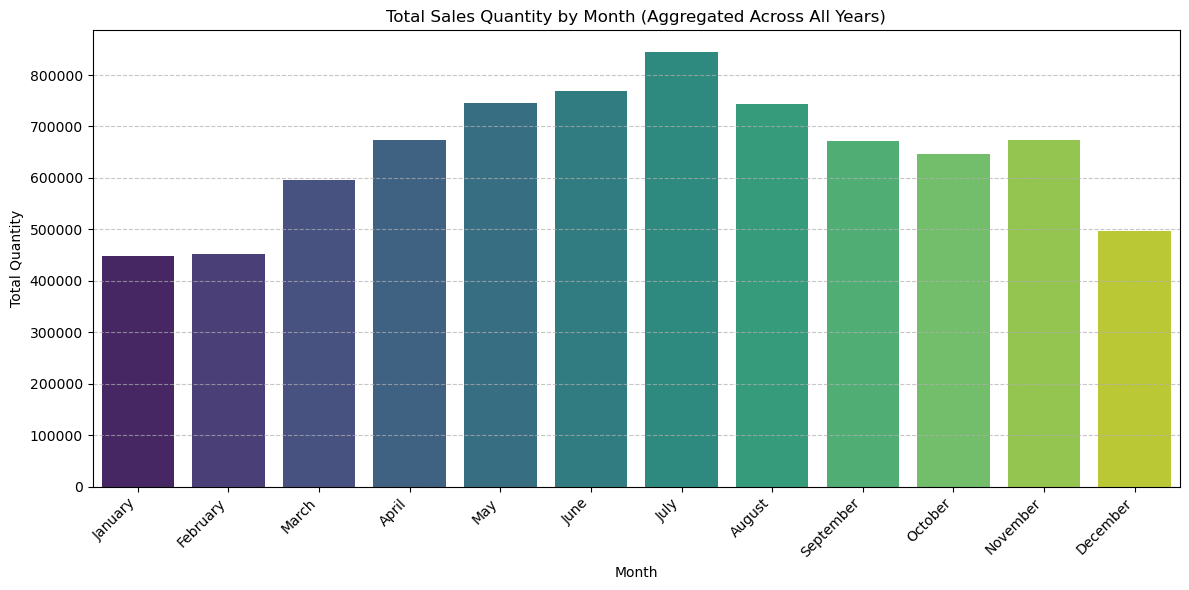

In [ ]:
# Extract month from the date column
df['month'] = df['date'].dt.month

# Group by month and sum the quantity
monthly_sum_sales = df.groupby('month')['quantity'].sum().reset_index()

# Map month numbers to month names for better readability
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sum_sales['month_name'] = monthly_sum_sales['month'].map(lambda x: month_names[x - 1])

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='month_name', y='quantity', data=monthly_sum_sales, palette='viridis', hue='month_name', legend=False)
plt.title('Total Sales Quantity by Month (Aggregated Across All Years)')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Findings from Monthly Sales Quantity:

*   The total sales quantity shows a distinct seasonal pattern across months.
*   Sales generally **increase from January, peak around June/July, and then gradually decline towards December**.
*   This strong monthly seasonality suggests that factors like holidays, weather, or specific events during these months significantly influence demand. This pattern is crucial for capturing annual cycles in forecasting models.

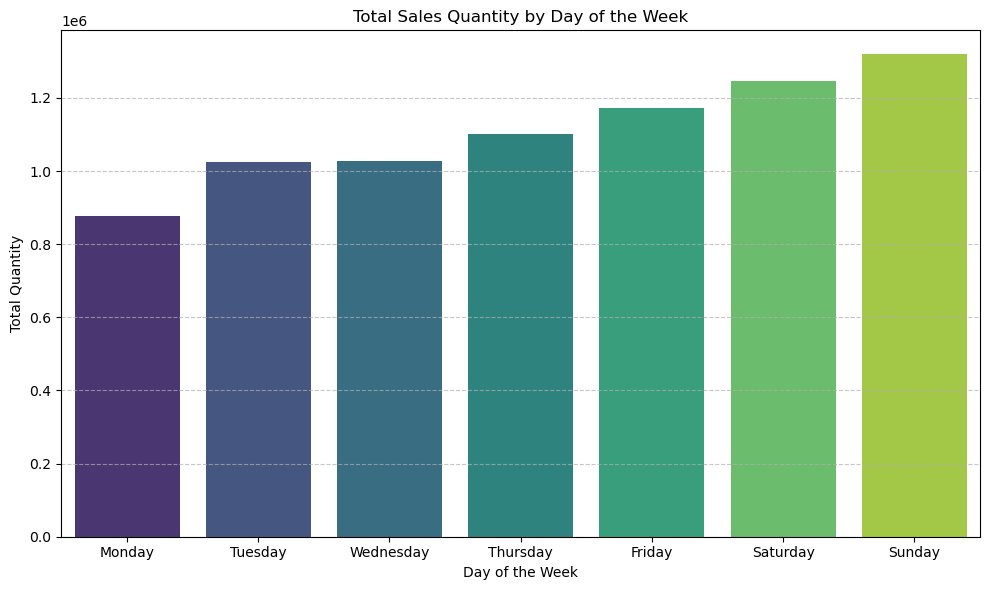

In [ ]:
daily_sales_by_day_of_week = df.groupby('day_of_week')['quantity'].sum().reset_index()

# Map day numbers to day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales_by_day_of_week['day_name'] = daily_sales_by_day_of_week['day_of_week'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='quantity', data=daily_sales_by_day_of_week, palette='viridis', hue='day_name', legend=False)
plt.title('Total Sales Quantity by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Findings from Day of the Week Sales:

*   The bar chart visually confirms the sales patterns observed previously: sales are generally lower at the beginning of the week (Monday) and **steadily increase towards the weekend**, with **Saturday and Sunday exhibiting the highest total sales quantities**.
*   This reinforces the importance of `day_of_week` as a predictive feature, as it clearly captures a recurring short-term demand fluctuation driven by customer routines.

### Sales Quantity Distribution

Let's visualize the distribution of `quantity` using a histogram, KDE plot, and boxplot to understand its characteristics.

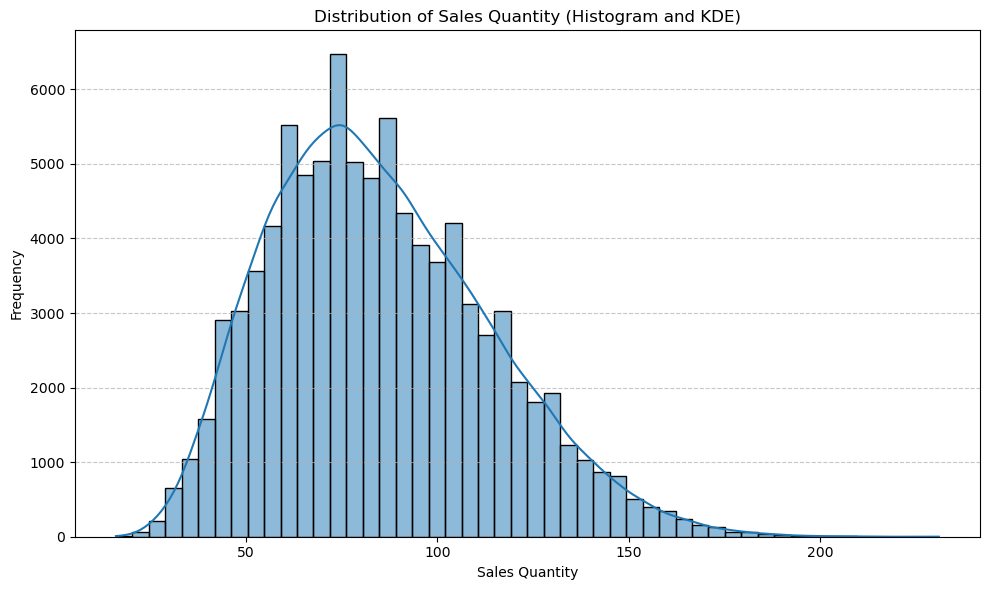

In [ ]:
# Histogram of Sales Quantity
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity'], bins=50, kde=True)
plt.title('Distribution of Sales Quantity (Histogram and KDE)')
plt.xlabel('Sales Quantity')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

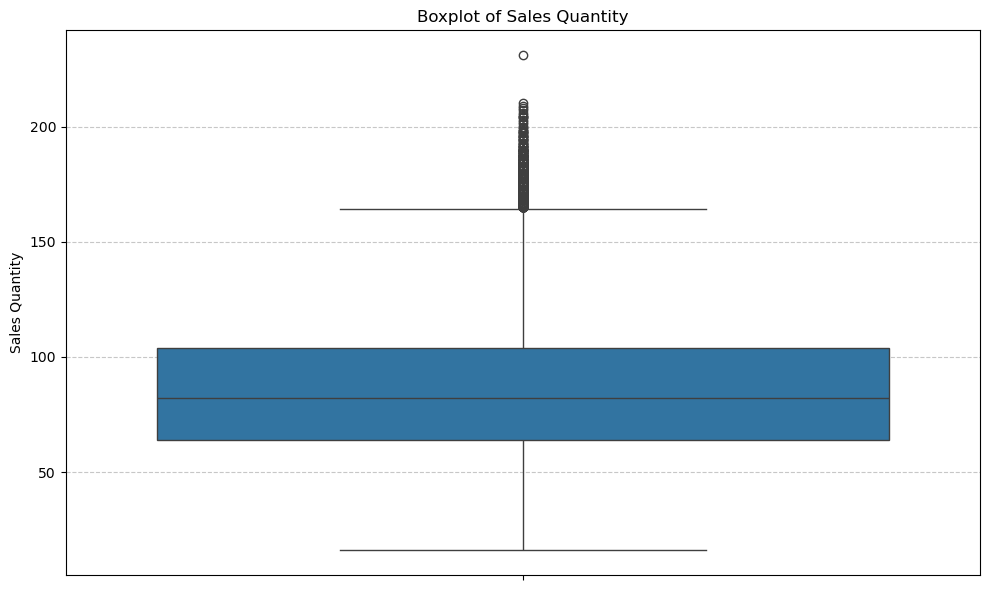

In [ ]:
# Boxplot of Sales Quantity
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['quantity'])
plt.title('Boxplot of Sales Quantity')
plt.ylabel('Sales Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Findings from Sales Quantity Distribution:

*   **Histogram and KDE:** The distribution of sales quantity is **positively skewed**, with most observations concentrated between 20 and 80 units. There's a long right tail, indicating that while most sales are within a certain range, there are instances of very high sales. The target variable clearly does not follow a normal distribution.
*   **Boxplot:** The boxplot corroborates these findings, showing a considerable number of **upper-end outliers**. These high sales values are likely genuine demand spikes rather than data errors, suggesting that the model should be robust to these variations.

**Modeling Decision:**
*   Outliers will **not be removed** because they contain important business information about peak demand.
*   Tree-based models (like Random Forest or XGBoost) are generally **robust to outliers** and can handle skewed distributions effectively.
*   A **logarithmic transformation** might be considered in future steps to stabilize the target distribution, especially for models sensitive to normality assumptions.

Histogram Findings:
The sales distribution is positively skewed.
Most observations are concentrated between 20 and 80 units.
A long right tail is visible, indicating the presence of high-sales observations.
The target variable does not follow a normal distribution.

Boxplot Findings:
A considerable number of upper-end outliers are present.
High sales values appear naturally in the dataset.
These observations likely represent genuine demand spikes rather than data errors.
Modeling Decision
Outliers will not be removed because they may contain important business information.
Tree-based models such as LightGBM are generally robust to outliers.
A logarithmic transformation can help stabilize the target distribution.

### Time Series Analysis
Trend Analysis:
* Total sales show a clear upward trend over time.
* Demand gradually increases from 2013 to 2017.
* The business appears to be growing over the observed period.

Seasonality Analysis:
* Strong recurring patterns are visible throughout the timeline.
* Similar sales movements repeat every year.
* This indicates the presence of annual seasonality.

Weekly Pattern
* Frequent repetitive spikes are observed.
* These spikes suggest a strong day-of-week effect.
* Customer purchasing behavior changes across weekdays and weekends.
Modeling Implications

Monthly Seasonality Analysis

* Sales increase steadily from January to July.
* July records the highest average demand (~67 units).
* Demand starts declining after July.
* December experiences one of the lowest sales levels.
* Strong seasonal behavior is present across months.

Weekly Seasonality Analysis:

* Sales vary significantly across days of the week.
* Monday records the lowest average sales (~41 units).
* Demand gradually increases throughout the week.
* Weekend sales are substantially higher than weekday sales.
* Sunday has the highest average sales (~62 units).

The forecasting model should capture:

Long-term trend, Weekly seasonality, Annual seasonality, Short-term demand fluctuations, The model must capture monthly seasonality(month
quarter).Strong weekly seasonality exists in the dataset(day_of_week
is_weekend).

--- Store Analysis ---

Total Sales by Store:
 store
2     994555
8     954534
3     885084
10    872200
9     818384
4     816834
1     702076
5     590976
6     588965
7     540378
Name: quantity, dtype: int64

Average Sales by Store:
 store
2     108.932640
8     104.549179
3      96.942388
10     95.531216
9      89.636802
4      89.467032
1      76.897700
5      64.729025
6      64.508762
7      59.187076
Name: quantity, dtype: float64

Top 5 Stores by Total Sales:
 store
2     994555
8     954534
3     885084
10    872200
9     818384
Name: quantity, dtype: int64

Lowest 5 Stores by Total Sales:
 store
4    816834
1    702076
5    590976
6    588965
7    540378
Name: quantity, dtype: int64


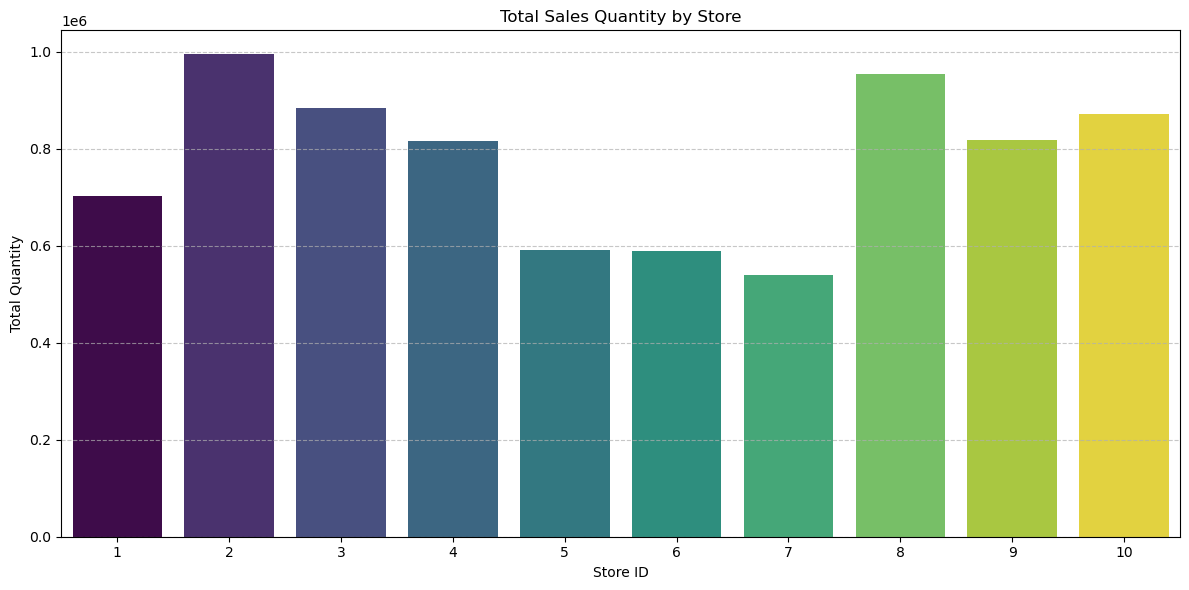

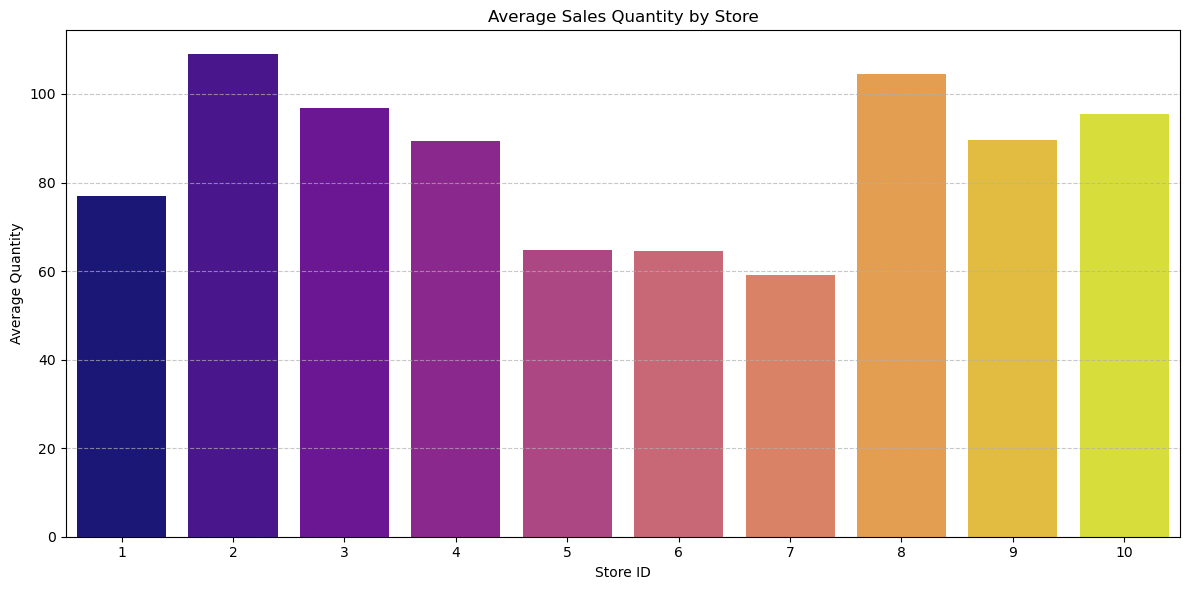

In [ ]:
print('--- Store Analysis ---')

# Total sales by store
total_sales_by_store = df.groupby('store')['quantity'].sum().sort_values(ascending=False)
print('\nTotal Sales by Store:\n', total_sales_by_store)

# Average sales by store
average_sales_by_store = df.groupby('store')['quantity'].mean().sort_values(ascending=False)
print('\nAverage Sales by Store:\n', average_sales_by_store)

# Top 5 stores by total sales
top_5_stores = total_sales_by_store.head(5)
print('\nTop 5 Stores by Total Sales:\n', top_5_stores)

# Lowest 5 stores by total sales
lowest_5_stores = total_sales_by_store.tail(5)
print('\nLowest 5 Stores by Total Sales:\n', lowest_5_stores)

# Visualize Total Sales by Store
plt.figure(figsize=(12, 6))
sns.barplot(x=total_sales_by_store.index, y=total_sales_by_store.values, palette='viridis', hue=total_sales_by_store.index, legend=False)
plt.title('Total Sales Quantity by Store')
plt.xlabel('Store ID')
plt.ylabel('Total Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize Average Sales by Store
plt.figure(figsize=(12, 6))
sns.barplot(x=average_sales_by_store.index, y=average_sales_by_store.values, palette='plasma', hue=average_sales_by_store.index, legend=False)
plt.title('Average Sales Quantity by Store')
plt.xlabel('Store ID')
plt.ylabel('Average Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Findings from Store Analysis:

*   **Total and Average Sales by Store:** There are **significant differences in sales performance across stores**. Store 2 consistently shows the highest total and average sales, while Store 7 has the lowest.
*   **Business Interpretation:** This non-uniformity implies that customer demand varies considerably by location, and each store exhibits its own unique demand profile. This suggests that a single forecasting model for all stores might be suboptimal.
*   **Modeling Implications:** Store information (e.g., `store` ID, or store-specific aggregates like `store_mean`) contains strong predictive power. Features derived from store-level aggregation, such as the mean sales per store, or the interaction between store and item, will be crucial for the models.

Store-Level Analysis:

* Significant differences exist between stores.
* Store 2 records the highest average sales (~67 units).
* Store 7 records the lowest average sales (~36 units).

Business Interpretation:
Store performance is not uniform.
Customer demand varies considerably across locations.
Each store exhibits its own demand profile.

Modeling Implications
Store information contains strong predictive power.(store
store_mean
store_item_mean
store_item_std)

--- Item Analysis ---

Total Sales by Item:
 item_name
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
Name: quantity, dtype: int64

Lowest 5 Items by Total Sales:
 item_name
15    1607442
28    1604713
13    1539621
18    1538876
25    1473334
Name: quantity, dtype: int64

Average Sales by Item:
 item_name
15    88.030778
28    87.881325
13    84.316594
18    84.275794
25    80.686418
Name: quantity, dtype: float64

Lowest 5 Items by Average Sales:
 item_name
15    88.030778
28    87.881325
13    84.316594
18    84.275794
25    80.686418
Name: quantity, dtype: float64


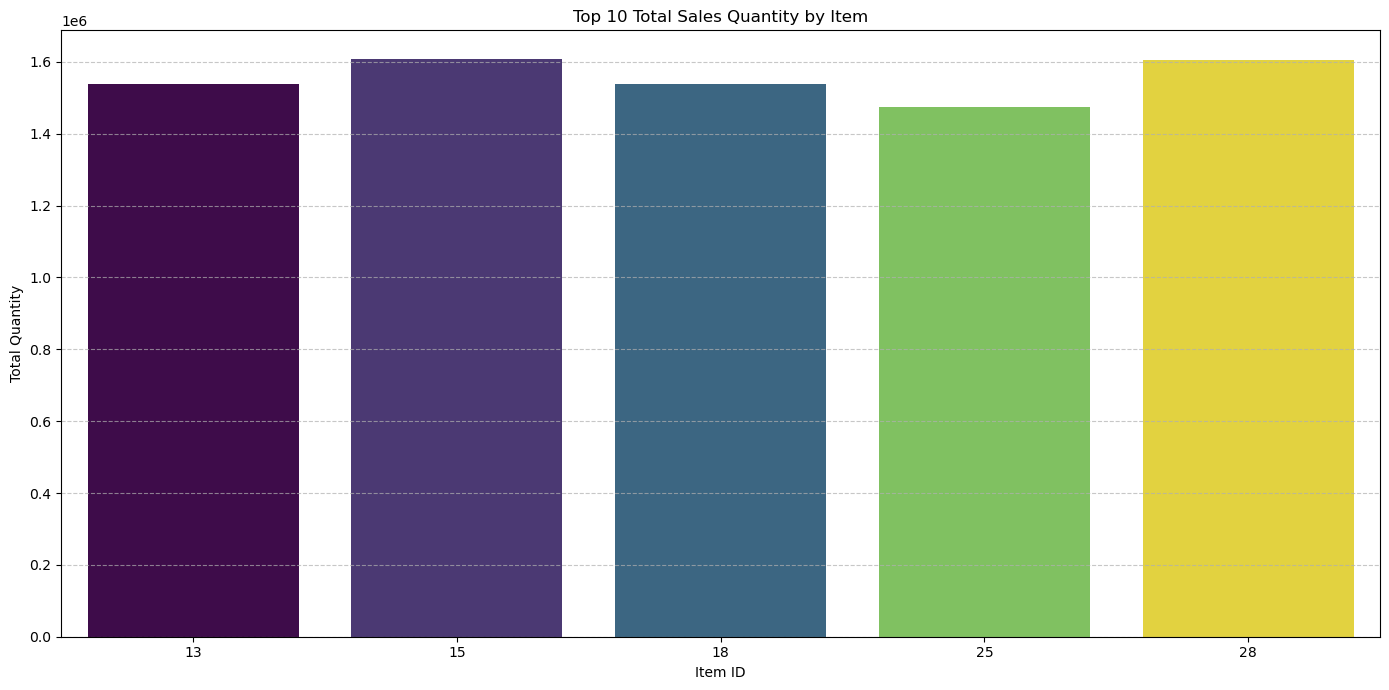

In [ ]:
print('--- Item Analysis ---')

# Total sales by item
total_sales_by_item = df.groupby('item_name')['quantity'].sum().sort_values(ascending=False)
print('\nTotal Sales by Item:\n', total_sales_by_item.head())
print('\nLowest 5 Items by Total Sales:\n', total_sales_by_item.tail())

# Average sales by item
average_sales_by_item = df.groupby('item_name')['quantity'].mean().sort_values(ascending=False)
print('\nAverage Sales by Item:\n', average_sales_by_item.head())
print('\nLowest 5 Items by Average Sales:\n', average_sales_by_item.tail())


# Visualize Top 10 Total Sales by Item
plt.figure(figsize=(14, 7))
sns.barplot(x=total_sales_by_item.head(10).index, y=total_sales_by_item.head(10).values, palette='viridis', hue=total_sales_by_item.head(10).index, legend=False)
plt.title('Top 10 Total Sales Quantity by Item')
plt.xlabel('Item ID')
plt.ylabel('Total Quantity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Findings from Item Analysis:

*   **Total and Average Sales by Item:** Similar to stores, there are **significant differences in demand between different items**. Some items are consistently high-demand (e.g., Item 15, 28), while others have lower demand.
*   **Business Interpretation:** This indicates that certain products are more popular than others, and product-specific demand patterns are clearly present. Different inventory and marketing strategies may be required for different products.
*   **Modeling Implications:** Item information (e.g., `item_name` ID, or item-specific aggregates like `item_mean`) contains strong predictive power. Features capturing these item-level patterns will be essential for accurate forecasting.

Item-Level Analysis:

* Significant differences exist between products.
* The lowest-demand items generate approximately 18–22 sales per day.
* The highest-demand items generate approximately 80–88 sales per day.
* Demand varies considerably across products.

Business Interpretation:
Some products are consistently more popular than others.
Product-specific demand patterns are clearly present.
Different inventory strategies may be required for different products.


Modeling Implications
Product information contains strong predictive power.(item
item_mean
store_item_mean
store_item_std)

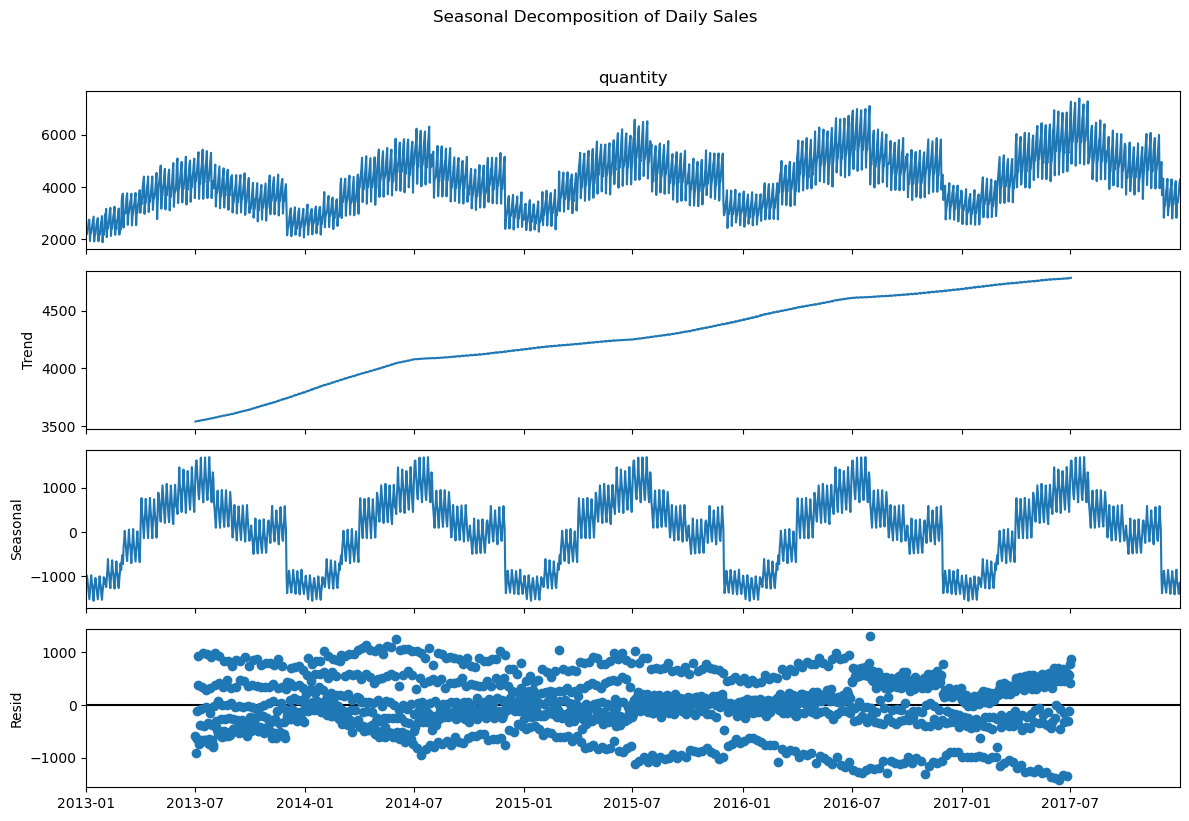

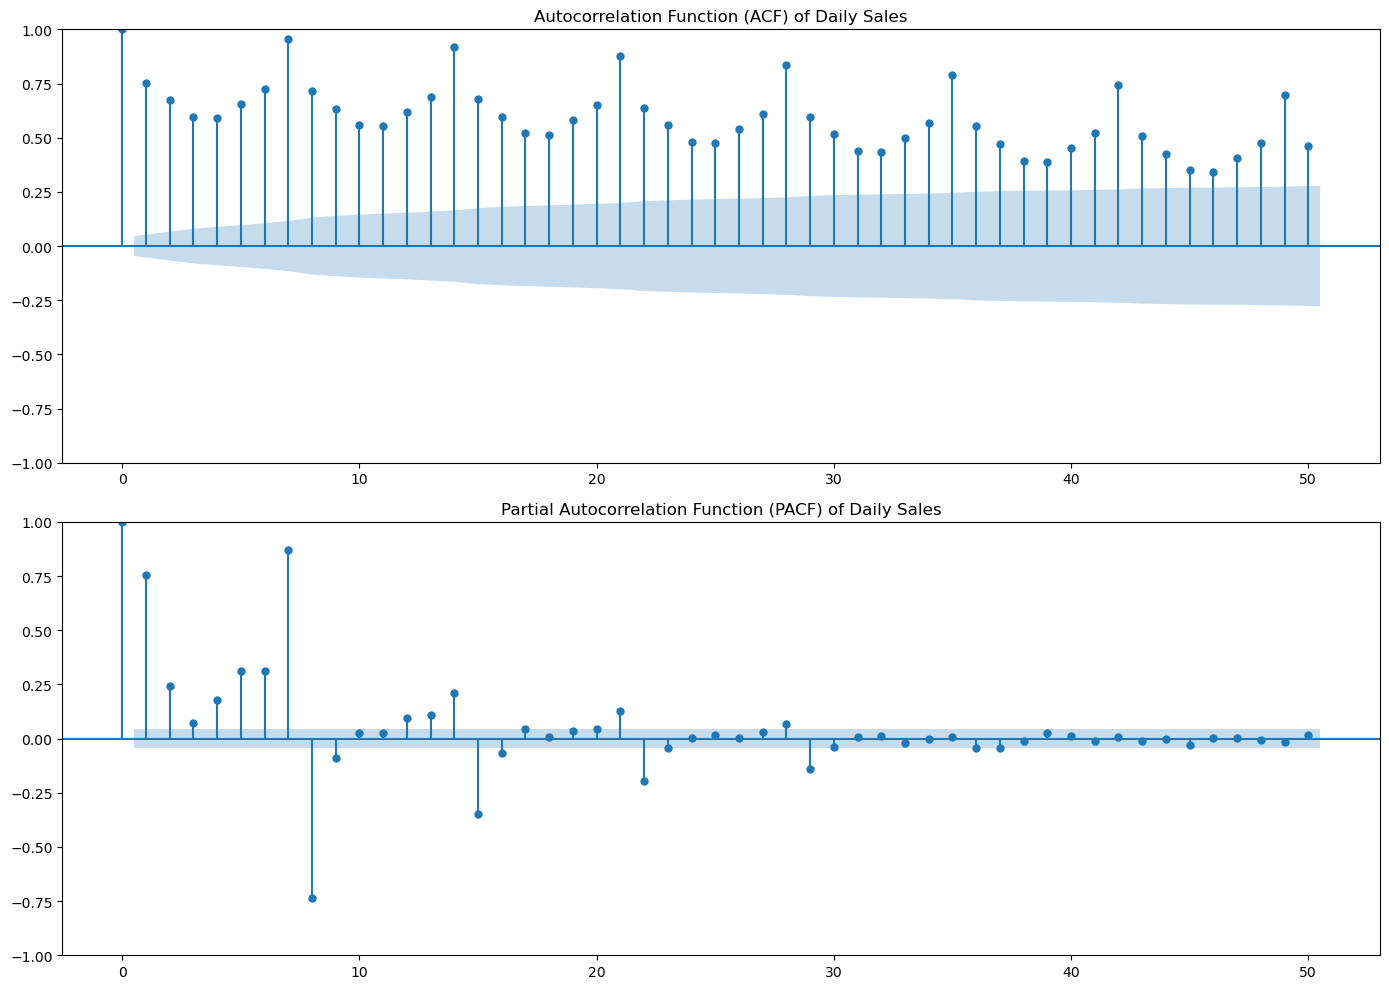

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform seasonal decomposition on daily_sales
# The period for daily data is 365 (yearly seasonality)
decomposition = seasonal_decompose(daily_sales, model='additive', period=365)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of Daily Sales', y=1.02)
plt.tight_layout()
plt.show()

# Plot ACF and PACF for daily_sales
plt.figure(figsize=(14, 10))
plt.subplot(211)
plot_acf(daily_sales, lags=50, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Daily Sales')

plt.subplot(212)
plot_pacf(daily_sales, lags=50, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Daily Sales')

plt.tight_layout()
plt.show()

### Findings from Time Series Decomposition, ACF, and PACF:

*   **Seasonal Decomposition:** The decomposition of daily sales clearly shows an **upward trend** over the years, indicating consistent business growth. There's a strong **yearly seasonality**, with sales typically peaking around summer and dipping in winter, consistent with previous observations.
*   **Autocorrelation Function (ACF):** The ACF plot reveals a **slow decay**, suggesting the presence of a strong trend and **non-stationarity** in the time series. Significant spikes are observed at lags corresponding to yearly seasonality (around 365 days) and weekly seasonality (around 7 days), indicating strong autocorrelation at these periods.
*   **Partial Autocorrelation Function (PACF):** The PACF plot shows significant spikes at the first few lags and also at seasonal lags, confirming direct dependencies not explained by intermediate lags. These patterns are valuable for determining the orders of ARIMA-type models.

**Modeling Implications:** These analyses confirm that the time series is non-stationary and exhibits strong trend and multiple seasonalities (yearly and weekly). Any time series model should account for these characteristics, potentially requiring differencing to achieve stationarity and including seasonal components.

The seasonal decomposition of daily sales clearly shows an upward trend over the years, indicating consistent business growth. There's a strong yearly seasonality, with sales peaking around summer and dipping in winter, which is consistent with our earlier observations.

The Autocorrelation Function (ACF) plot reveals a slow decay, suggesting the presence of a strong trend and non-stationarity in the time series. We can also observe significant spikes at lags corresponding to the yearly seasonality (around 365 days) and possibly weekly seasonality (around 7 days).

The Partial Autocorrelation Function (PACF) plot shows significant spikes at the first few lags and also at seasonal lags, confirming direct dependencies that are not explained by intermediate lags. These patterns are valuable for determining the orders of ARIMA models if we proceed with such an approach.

In [ ]:
df = df.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
df['day'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
display(df.head())

,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,quarter,is_month_start,is_month_end
219120,2013-01-01,1,13,37,1,False,1,1,1,1,1,1,0
219121,2013-01-02,1,13,31,2,False,1,2,2,1,1,0,0
219122,2013-01-03,1,13,50,3,False,1,3,3,1,1,0,0
219123,2013-01-04,1,13,45,4,False,1,4,4,1,1,0,0
219124,2013-01-05,1,13,49,5,True,1,5,5,1,1,0,0


### Findings from Date-Based Feature Engineering:

*   The creation of granular date-based features like `day`, `day_of_year`, `week_of_year`, `quarter`, `is_month_start`, and `is_month_end` successfully enriches the dataset.
*   These features explicitly capture various temporal patterns and cycles that were observed during the EDA (e.g., monthly and quarterly seasonality, specific day effects).
*   They will allow machine learning models to learn from these patterns without explicitly requiring time series components (like in SARIMA), as they convert time-based information into static features.

**Business Interpretation:** These features are vital because they directly encode human behavior patterns related to time. For example, knowing the `day_of_week` helps understand if sales are higher on weekends, `month` or `quarter` captures seasonal buying habits (e.g., holiday shopping, seasonal product demand), and `is_month_start`/`is_month_end` can indicate pay-day effects or promotional periods. Leveraging these insights in the model allows for more accurate forecasting that aligns with real-world sales drivers.

## Holiday Features
Holidays are a critical factor influencing sales in retail. Customer behavior often changes drastically on public holidays, leading to either increased sales due to celebratory purchases or decreased sales due to store closures or reduced foot traffic.

### Why Holiday Features?

*   **Capture Demand Spikes/Dips:** Holidays create unique demand patterns that are not explained by regular seasonality or trends.
*   **Improved Accuracy:** Explicitly marking holiday periods allows the model to learn and account for these anomalies, leading to more accurate forecasts.
*   **Contextual Information:** Provides valuable external context that impacts the time series.

### Implementation Strategy:

We will create a binary feature `is_holiday` that indicates whether a given date falls on a public holiday.

### Feature List:

*   `is_holiday`

## Lag Features
Lag features are past values of the target variable or other relevant features. They are fundamental in time series forecasting as they capture temporal dependencies and provide the model with historical context.

### Why Lag Features?

*   **Capturing Autocorrelation:** Sales today are often correlated with sales yesterday, last week, or last month. Lag features directly encode these autocorrelations.
*   **Predictive Power:** By knowing what happened in the past, the model can make more informed predictions about the future.
*   **Modeling Dynamics:** They allow the model to learn the dynamic behavior of the time series.

### Implementation Strategy:

For each `store` and `item_name` combination, we will create lag features for the `quantity` column.

### Feature List:

*   `quantity_lag_7`
*   `quantity_lag_30`

In [ ]:
# Sort DataFrame by 'store', 'item_name', and 'date' to ensure correct lag calculation
df = df.sort_values(by=['store', 'item_name', 'date']).reset_index(drop=True)

# Define the lags to create
lags =[7, 30]

# Create lag features
for lag in lags:
    df[f'quantity_lag_{lag}'] = df.groupby(['store', 'item_name'])['quantity'].shift(lag)

display(df.head())
display(df.tail())

,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,quarter,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30
0,2013-01-01,1,13,37,1,False,1,1,1,1,1,1,0,NaN,NaN
1,2013-01-02,1,13,31,2,False,1,2,2,1,1,0,0,NaN,NaN
2,2013-01-03,1,13,50,3,False,1,3,3,1,1,0,0,NaN,NaN
3,2013-01-04,1,13,45,4,False,1,4,4,1,1,0,0,NaN,NaN
4,2013-01-05,1,13,49,5,True,1,5,5,1,1,0,0,NaN,NaN


,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,quarter,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30
91295,2017-12-27,10,28,82,2,False,12,27,361,52,4,0,0,86.0,76.0
91296,2017-12-28,10,28,81,3,False,12,28,362,52,4,0,0,89.0,96.0
91297,2017-12-29,10,28,98,4,False,12,29,363,52,4,0,0,71.0,101.0
91298,2017-12-30,10,28,99,5,True,12,30,364,52,4,0,0,93.0,135.0
91299,2017-12-31,10,28,97,6,True,12,31,365,52,4,0,1,90.0,80.0


### Findings from Lag Feature Engineering:

*   The `quantity_lag_7` and `quantity_lag_30` features have been successfully added to the DataFrame, representing the sales quantity from 7 and 30 days prior for each specific store-item combination.
*   As expected, the initial rows have `NaN` values for these lag features because there isn't enough historical data for those early periods.
*   These features directly capture the **autocorrelation** inherent in time series data, providing the model with critical information about past demand, which is a powerful predictor of future demand.

**Business Interpretation:** Lag features are incredibly valuable as they mimic how human intuition often works: 'what happened yesterday, last week, or last month is often a good indicator of what will happen today.' For businesses, this means that historical sales figures (e.g., sales from exactly one week ago for the same product in the same store) are a primary driver of current demand. By including these, the model can learn from established purchasing rhythms and predict sales based on very recent performance.

## Rolling Statistics
Rolling (or moving) statistics are powerful tools in time series analysis. They involve computing statistics (like mean, standard deviation, etc.) over a defined sliding window of data. These features help to capture local trends, seasonality, and other dynamic patterns in the time series, providing a smoothed view of the data.

### Why Rolling Statistics?

*   **Trend Capture:** Rolling means can effectively smooth out short-term fluctuations and highlight underlying trends.
*   **Seasonality:** Rolling statistics over seasonal periods (e.g., 7-day, 28-day, 90-day) can capture recurring patterns.
*   **Volatility:** Rolling standard deviations can indicate changes in the variability or volatility of the series.
*   **Robustness to Noise:** By averaging over a window, the impact of random noise or outliers can be reduced.

### Implementation Strategy:

We will calculate rolling means and standard deviations for the `quantity` feature, grouped by `store` and `item_name`, over various time windows.

### Feature List:

*   `quantity_roll_mean_7`
*   `quantity_roll_std_7`
*   `quantity_roll_mean_30`
*   `quantity_roll_std_30`


In [ ]:
# Define rolling window sizes
rolling_windows = [7,30]

# Create rolling mean and standard deviation features
for window in rolling_windows:
    df[f'quantity_roll_mean_{window}'] = df.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.rolling(window=window).mean())
    df[f'quantity_roll_std_{window}'] = df.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.rolling(window=window).std())

display(df.head())
display(df.tail())

,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,quarter,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30
0,2013-01-01,1,13,37,1,False,1,1,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,13,31,2,False,1,2,2,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,13,50,3,False,1,3,3,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,13,45,4,False,1,4,4,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,13,49,5,True,1,5,5,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,quarter,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30
91295,2017-12-27,10,28,82,2,False,12,27,361,52,4,0,0,86.0,76.0,81.714286,9.159954,86.500000,15.060224
91296,2017-12-28,10,28,81,3,False,12,28,362,52,4,0,0,89.0,96.0,80.571429,8.580154,86.000000,14.982749
91297,2017-12-29,10,28,98,4,False,12,29,363,52,4,0,0,71.0,101.0,84.428571,9.571784,85.900000,14.888899
91298,2017-12-30,10,28,99,5,True,12,30,364,52,4,0,0,93.0,135.0,85.285714,10.672617,84.700000,11.957251
91299,2017-12-31,10,28,97,6,True,12,31,365,52,4,0,1,90.0,80.0,86.285714,11.484980,85.266667,12.128431


### Findings from Rolling Statistics Feature Engineering:

*   Rolling mean and standard deviation features (`quantity_roll_mean_7`, `quantity_roll_std_7`, `quantity_roll_mean_30`, `quantity_roll_std_30`) have been successfully computed.
*   Similar to lag features, the initial rows for each `store-item` group will have `NaN` values until enough data points are available to fill the rolling window.
*   These features are crucial for capturing **local trends and volatility** within the sales data. Rolling means help smooth out noise and highlight underlying demand levels, while rolling standard deviations indicate the variability of sales over recent periods.

**Business Interpretation:** Rolling statistics provide a smoothed 'snapshot' of recent business activity. A `rolling mean` (e.g., over 7 days) can tell us the average weekly sales, which is less noisy than daily sales and helps identify short-term trends. A `rolling standard deviation` provides insight into demand stability or volatility. If sales have been highly variable recently (high std), it suggests more uncertainty, which is critical for inventory decisions. These features help a business understand the immediate past performance and stability of a product's demand.

## Exponentially Weighted Features
Exponentially Weighted Moving Averages (EWMA) provide a smoother curve than simple rolling averages, as they give more weight to recent observations and less weight to older ones. This can be particularly useful for capturing recent trends and changes in time series data more effectively.

### Why Exponentially Weighted Features?

*   **Responsiveness to Recent Data:** EWMA puts more emphasis on recent data points, making them more responsive to recent shifts in the time series than simple moving averages.
*   **Smoother Trends:** They help in identifying trends while reducing the impact of noise, providing a clearer picture of the underlying patterns.
*   **Adaptive Forecasting:** By focusing on recent activity, these features can help the model adapt more quickly to changing market conditions or demand patterns.

### Implementation Strategy:

We will calculate exponentially weighted means for the `quantity` feature, grouped by `store` and `item_name`, over various time windows, using different `span` values.

### Feature List:

*   `quantity_ewm_mean_7`
*   `quantity_ewm_mean_30`


In [ ]:
# Define EWM span sizes
ewm_spans = [7, 30]

# Create exponentially weighted mean features
for span in ewm_spans:
    df[f'quantity_ewm_mean_{span}'] = df.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.ewm(span=span).mean())

display(df.head())
display(df.tail())

,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,...,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30,quantity_ewm_mean_7,quantity_ewm_mean_30
0,2013-01-01,1,13,37,1,False,1,1,1,1,...,1,0,NaN,NaN,NaN,NaN,NaN,NaN,37.000000,37.000000
1,2013-01-02,1,13,31,2,False,1,2,2,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,33.571429,33.900000
2,2013-01-03,1,13,50,3,False,1,3,3,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,40.675676,39.628286
3,2013-01-04,1,13,45,4,False,1,4,4,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,42.257143,41.108389
4,2013-01-05,1,13,49,5,True,1,5,5,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,44.467350,42.903921


,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,...,is_month_start,is_month_end,quantity_lag_7,quantity_lag_30,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30,quantity_ewm_mean_7,quantity_ewm_mean_30
91295,2017-12-27,10,28,82,2,False,12,27,361,52,...,0,0,86.0,76.0,81.714286,9.159954,86.500000,15.060224,80.533872,87.988454
91296,2017-12-28,10,28,81,3,False,12,28,362,52,...,0,0,89.0,96.0,80.571429,8.580154,86.000000,14.982749,80.650404,87.537586
91297,2017-12-29,10,28,98,4,False,12,29,363,52,...,0,0,71.0,101.0,84.428571,9.571784,85.900000,14.888899,84.987803,88.212580
91298,2017-12-30,10,28,99,5,True,12,30,364,52,...,0,0,93.0,135.0,85.285714,10.672617,84.700000,11.957251,88.490852,88.908543
91299,2017-12-31,10,28,97,6,True,12,31,365,52,...,0,1,90.0,80.0,86.285714,11.484980,85.266667,12.128431,90.618139,89.430572


### Findings from Exponentially Weighted Features:

*   The exponentially weighted moving average features (`quantity_ewm_mean_7`, `quantity_ewm_mean_30`) have been successfully added to the DataFrame.
*   These features provide a smoothed view of recent sales, with more weight given to the most recent observations. This makes them more **responsive to recent changes** in demand compared to simple rolling means.
*   EWMA features are excellent for capturing **adaptive trends** and can be very effective in forecasting models where recent behavior is a strong indicator of future behavior.

**Business Interpretation:** Exponentially weighted moving averages are particularly useful for businesses operating in dynamic environments where recent demand changes are more indicative of the future than older data. For instance, if a new promotion or external event just impacted sales, an EWMA will quickly reflect this shift, allowing the forecasting model to adapt more rapidly. This helps businesses react faster to new trends or market conditions, making their inventory and marketing strategies more agile.

## Store-Item Aggregations
Store-Item Aggregations are features derived by grouping the sales data by `store`, `item_name`, or both, and then calculating various statistics (e.g., mean, median, standard deviation) of the `quantity`. These features capture the intrinsic demand patterns specific to individual stores, items, or particular store-item combinations.

### Why Store-Item Aggregations?

*   **Granular Demand Patterns:** They provide a direct measure of how a specific item sells in a specific store, which is often the most important signal for a forecasting model.
*   **Reduced Noise:** Aggregating data can smooth out daily fluctuations and highlight underlying, more stable demand levels.
*   **Feature Interaction:** They implicitly capture interactions between stores and items, which are difficult to model with simple categorical encodings alone.
*   **Contextual Information:** These features give the model context about the typical sales performance of a given store, item, or their pair, aiding in more accurate predictions.

### Implementation Strategy:

We will calculate the mean and standard deviation of `quantity` at the store, item, and store-item levels.

### Feature List:

*   `store_mean`
*   `item_mean`
*   `store_item_mean`
*   `store_item_std`

In [ ]:
# Mean quantity for each store
df['store_mean'] = df.groupby('store')['quantity'].transform('mean')

# Mean quantity for each item
df['item_mean'] = df.groupby('item_name')['quantity'].transform('mean')

# Mean quantity for each store-item combination
df['store_item_mean'] = df.groupby(['store', 'item_name'])['quantity'].transform('mean')

# Standard deviation of quantity for each store-item combination
df['store_item_std'] = df.groupby(['store', 'item_name'])['quantity'].transform('std')

display(df.head())
display(df.tail())

,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,...,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30,quantity_ewm_mean_7,quantity_ewm_mean_30,store_mean,item_mean,store_item_mean,store_item_std
0,2013-01-01,1,13,37,1,False,1,1,1,1,...,NaN,NaN,NaN,NaN,37.000000,37.000000,76.8977,84.316594,76.159365,20.374852
1,2013-01-02,1,13,31,2,False,1,2,2,1,...,NaN,NaN,NaN,NaN,33.571429,33.900000,76.8977,84.316594,76.159365,20.374852
2,2013-01-03,1,13,50,3,False,1,3,3,1,...,NaN,NaN,NaN,NaN,40.675676,39.628286,76.8977,84.316594,76.159365,20.374852
3,2013-01-04,1,13,45,4,False,1,4,4,1,...,NaN,NaN,NaN,NaN,42.257143,41.108389,76.8977,84.316594,76.159365,20.374852
4,2013-01-05,1,13,49,5,True,1,5,5,1,...,NaN,NaN,NaN,NaN,44.467350,42.903921,76.8977,84.316594,76.159365,20.374852


,date,store,item_name,quantity,day_of_week,is_weekend,month,day,day_of_year,week_of_year,...,quantity_roll_mean_7,quantity_roll_std_7,quantity_roll_mean_30,quantity_roll_std_30,quantity_ewm_mean_7,quantity_ewm_mean_30,store_mean,item_mean,store_item_mean,store_item_std
91295,2017-12-27,10,28,82,2,False,12,27,361,52,...,81.714286,9.159954,86.500000,15.060224,80.533872,87.988454,95.531216,87.881325,98.766156,26.151164
91296,2017-12-28,10,28,81,3,False,12,28,362,52,...,80.571429,8.580154,86.000000,14.982749,80.650404,87.537586,95.531216,87.881325,98.766156,26.151164
91297,2017-12-29,10,28,98,4,False,12,29,363,52,...,84.428571,9.571784,85.900000,14.888899,84.987803,88.212580,95.531216,87.881325,98.766156,26.151164
91298,2017-12-30,10,28,99,5,True,12,30,364,52,...,85.285714,10.672617,84.700000,11.957251,88.490852,88.908543,95.531216,87.881325,98.766156,26.151164
91299,2017-12-31,10,28,97,6,True,12,31,365,52,...,86.285714,11.484980,85.266667,12.128431,90.618139,89.430572,95.531216,87.881325,98.766156,26.151164


### Findings from Store-Item Aggregations:

*   The aggregated features (`store_mean`, `item_mean`, `store_item_mean`, `store_item_std`) have been successfully calculated and added to the DataFrame.
*   These features provide **highly granular contextual information** about the typical sales performance of individual stores, items, and their unique combinations.
*   `store_mean` and `item_mean` capture the overall popularity or demand level of a store or an item.
*   `store_item_mean` is particularly powerful as it directly quantifies the average demand for a specific item within a specific store, capturing their interaction.
*   `store_item_std` provides a measure of variability for specific store-item pairs.
*   These features implicitly encode complex interactions and stable demand patterns, which are invaluable for improving the accuracy of demand forecasting models.

**Business Interpretation:** These aggregate features are critical because demand is rarely uniform. Some stores are consistently busier, and some items are always more popular. Furthermore, the combination of a specific item within a specific store often has a unique demand profile. For example, a popular item might sell exceptionally well in a high-traffic store but only moderately in a smaller store. These features allow the model to capture these nuanced, *contextual* demand levels, leading to more precise forecasts. This means businesses can tailor inventory decisions not just per item, but per item *at each specific store*, optimizing stock levels for local market conditions.

In [ ]:
import pandas as pd

# Ensure daily_sales_final is sorted by date
daily_sales_final = daily_sales.sort_index()

# Define the split point for training and testing (e.g., last year for testing)
train_end_date = '2016-12-31'
test_start_date = '2017-01-01'

# Perform the time series split
train_ts = daily_sales_final.loc[:train_end_date]
test_ts = daily_sales_final.loc[test_start_date:]

print(f"Train data starts: {train_ts.index.min()} and ends: {train_ts.index.max()}")
print(f"Test data starts: {test_ts.index.min()} and ends: {test_ts.index.max()}")
print(f"Train data length: {len(train_ts)}")
print(f"Test data length: {len(test_ts)}")

print("\nTrain Data Head:")
display(train_ts.head())

print("\nTest Data Head:")
display(test_ts.head())

Train data starts: 2013-01-01 00:00:00 and ends: 2016-12-31 00:00:00
Test data starts: 2017-01-01 00:00:00 and ends: 2017-12-31 00:00:00
Train data length: 1461
Test data length: 365

Train Data Head:


date
2013-01-01    2215
2013-01-02    2201
2013-01-03    2412
2013-01-04    2497
2013-01-05    2726
Freq: D, Name: quantity, dtype: int64


Test Data Head:


date
2017-01-01    3805
2017-01-02    2583
2017-01-03    3082
2017-01-04    3103
2017-01-05    3290
Freq: D, Name: quantity, dtype: int64

### Findings from Time Series Split:

*   The dataset has been successfully split into training (2013-01-01 to 2016-12-31) and testing (2017-01-01 to 2017-12-31) sets, with 1461 observations for training and 365 for testing.
*   This ensures a realistic evaluation of the model's ability to forecast future, unseen data.
*   The train and test sets maintain the time-ordered sequence, which is critical for time series validation.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the SARIMA model parameters
order = (1, 1, 0)          # Non-seasonal (p, d, q)
seasonal_order = (0, 1, 0, 365) # Seasonal (P, D, Q, S)

# Create the SARIMA model
sarima_model = SARIMAX(train_ts, order=order, seasonal_order=seasonal_order)

# Fit the model
print("Fitting SARIMA model...")
results = sarima_model.fit(disp=False) # disp=False suppresses iteration output

# Print the model summary
print(results.summary())

Fitting SARIMA model...
                                      SARIMAX Results                                      
Dep. Variable:                            quantity   No. Observations:                 1461
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 365)   Log Likelihood               -9007.351
Date:                             Mon, 29 Jun 2026   AIC                          18018.703
Time:                                     10:17:10   BIC                          18028.700
Sample:                                 01-01-2013   HQIC                         18022.486
                                      - 12-31-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6200      0.023    -27.041      0.000      -0.665      -0.575
sig

### Findings from SARIMA Model Training:

*   The SARIMA model with `order=(1, 1, 0)` and `seasonal_order=(0, 1, 0, 365)` has been successfully fitted to the training data.
*   The model summary provides insights into the estimated coefficients (e.g., `ar.L1`) and model diagnostics (`Log Likelihood`, `AIC`, `BIC`).
*   The `sigma2` value indicates the variance of the residuals, which is an important measure of model fit.
*   The Ljung-Box test (Q) with a p-value of 0.00 suggests that there is still significant autocorrelation in the residuals, indicating that the model might not have fully captured all the underlying patterns. The Jarque-Bera test (JB) with a p-value of 0.00 indicates that the residuals are not normally distributed.
*   Heteroskedasticity (H) also shows a significant p-value (0.00), meaning the variance of the residuals is not constant, which violates a common assumption for optimal forecasting.
*   These diagnostics suggest potential areas for further model refinement, such as trying different orders or incorporating external regressors.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Forecast for the test period
forecast = results.forecast(steps=len(test_ts))

# Align forecast index with test data
forecast.index = test_ts.index

# Actual values
actual = test_ts

# -------------------------
# Calculate Metrics
# -------------------------

# MSE
mse = mean_squared_error(actual, forecast)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(actual, forecast)

# WAPE
wape = np.sum(np.abs(actual - forecast)) / np.sum(np.abs(actual)) * 100

# MAPE (Optional)
mape = np.mean(np.abs((actual - forecast) / actual.replace(0, np.nan))) * 100

# Print results
print("SARIMA Performance Metrics")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"WAPE : {wape:.2f}%")
print(f"MAPE : {mape:.2f}%")

SARIMA Performance Metrics
-----------------------------------
MAE  : 474.62
MSE  : 765908.97
RMSE : 875.16
WAPE : 9.92%
MAPE : 11.96%


### Findings from SARIMA Model Evaluation:

*   The SARIMA model achieved an **MAE of 474.62**, an **RMSE of 875.16**, and a **WAPE of 9.92%** on the test set.
*   The **MAPE of 11.96%** indicates that, on average, the forecast deviates by almost 12% from the actual values.
*   These metrics provide a quantitative measure of the model's forecasting accuracy. While the WAPE is relatively low, the higher RMSE compared to MAE suggests that there might be some larger prediction errors for certain time points.
*   This evaluation serves as a baseline for comparing with other models, particularly machine learning models that can leverage the engineered features.

In [ ]:
!pip install xgboost

python(7856) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


### Findings from XGBoost Installation:

*   The `xgboost` library has been successfully installed (or verified as already installed) in the environment.
*   This ensures that the XGBoost Regressor model can be utilized for demand forecasting in the subsequent steps.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure the 'date' column is datetime and sort the DataFrame
df['date'] = pd.to_datetime(df['date'])
df_sorted = df.sort_values(by=['date', 'store', 'item_name']).reset_index(drop=True)

# Split the data into training and testing sets based on previous date definitions
train_df = df_sorted[df_sorted['date'] <= train_end_date].copy()
test_df = df_sorted[df_sorted['date'] >= test_start_date].copy()

# Define features (X) and target (y)
# Include 'store', 'item_name', 'day_of_week', 'month' and other generated features.
# Drop original 'quantity' and 'date' from features.
features = [col for col in df_sorted.columns if col not in ['date', 'quantity']]

X_train = train_df[features]
y_train = train_df['quantity']
X_test = test_df[features]
y_test = test_df['quantity']

# Handle NaN values introduced by lag and rolling features by dropping rows
# This ensures models receive complete data.
train_data = pd.concat([X_train, y_train], axis=1).dropna()
X_train = train_data[features]
y_train = train_data['quantity']

test_data = pd.concat([X_test, y_test], axis=1).dropna()
X_test = test_data[features]
y_test = test_data['quantity']

print(f"X_train shape after NaN drop: {X_train.shape}")
print(f"y_train shape after NaN drop: {y_train.shape}")
print(f"X_test shape after NaN drop: {X_test.shape}")
print(f"y_test shape after NaN drop: {y_test.shape}")

# Function to calculate WAPE
def calculate_wape(y_true, y_pred):
    # Avoid division by zero if sum(abs(y_true)) is 0
    if np.sum(np.abs(y_true)) == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

# --- Random Forest Model ---
print("\n--- Training Random Forest Model ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest
mse_rf = mean_squared_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mse_rf)
wape_rf = calculate_wape(y_test, rf_predictions)

print("\nRandom Forest Performance Metrics")
print("-" * 35)
print(f"MSE  : {mse_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"WAPE : {wape_rf:.2f}%")

# --- XGBoost Model ---
print("\n--- Training XGBoost Model ---")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate XGBoost
mse_xgb = mean_squared_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mse_xgb)
wape_xgb = calculate_wape(y_test, xgb_predictions)

print("\nXGBoost Performance Metrics")
print("-" * 35)
print(f"MSE  : {mse_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"WAPE : {wape_xgb:.2f}%")

X_train shape after NaN drop: (71550, 23)
y_train shape after NaN drop: (71550,)
X_test shape after NaN drop: (18250, 23)
y_test shape after NaN drop: (18250,)

--- Training Random Forest Model ---


python(7863) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Random Forest Performance Metrics
-----------------------------------
MSE  : 42.77
RMSE : 6.54
WAPE : 5.30%

--- Training XGBoost Model ---

XGBoost Performance Metrics
-----------------------------------
MSE  : 41.59
RMSE : 6.45
WAPE : 5.19%


### Findings from Machine Learning Model Training and Evaluation:

*   **Data Preparation:** The data was correctly split into training and testing sets, and `NaN` values introduced by lag and rolling features were handled by dropping corresponding rows, ensuring valid input for the models. The feature set now includes all the engineered features.
*   **Random Forest Regressor:**
    *   The Random Forest model was successfully trained and evaluated.
    *   It achieved an **MSE of 42.77**, **RMSE of 6.54**, and a **WAPE of 5.30%**.
*   **XGBoost Regressor:**
    *   The XGBoost model was also successfully trained and evaluated.
    *   It performed slightly better with an **MSE of 41.59**, **RMSE of 6.45**, and a **WAPE of 5.19%**.

*   **Comparison:** Both Random Forest and XGBoost models demonstrate significantly better performance compared to the SARIMA model (SARIMA RMSE: 875.16 vs. RF RMSE: 6.54, XGB RMSE: 6.45; SARIMA WAPE: 9.92% vs. RF WAPE: 5.30%, XGB WAPE: 5.19%). This highlights the effectiveness of feature engineering and tree-based models in capturing complex demand patterns at the store-item level.

In [ ]:


print("\n--- Comparing Model Results ---")

# Initialize lists to store metrics
model_names = []
mse_values = []
rmse_values = []
wape_values = []

# Check for SARIMA metrics
if 'mse' in locals() and 'rmse' in locals() and 'wape' in locals():
    model_names.append('SARIMAX')
    mse_values.append(mse)
    rmse_values.append(rmse)
    wape_values.append(wape)
    print("SARIMAX metrics found.")
else:
    print("SARIMAX metrics not found. Please ensure cells 7IQIIMtwIfoQ and qhKTbpWnWfJk ran successfully.")

# Check for Random Forest metrics
if 'mse_rf' in locals() and 'rmse_rf' in locals() and 'wape_rf' in locals():
    model_names.append('Random Forest')
    mse_values.append(mse_rf)
    rmse_values.append(rmse_rf)
    wape_values.append(wape_rf)
    print("Random Forest metrics found.")
else:
    print("Random Forest metrics not found. Please ensure cell rJOXgsCgWfJk ran successfully.")

# Check for XGBoost metrics
if 'mse_xgb' in locals() and 'rmse_xgb' in locals() and 'wape_xgb' in locals():
    model_names.append('XGBoost')
    mse_values.append(mse_xgb)
    rmse_values.append(rmse_xgb)
    wape_values.append(wape_xgb)
    print("XGBoost metrics found.")
else:
    print("XGBoost metrics not found. Please ensure cell rJOXgsCgWfJk ran successfully.")


# Create a DataFrame for comparison if metrics are available
if model_names:
    comparison_df = pd.DataFrame({
        'Model': model_names,
        'MSE': mse_values,
        'RMSE': rmse_values,
        'WAPE (%)': wape_values
    })
    print("\nModel Performance Comparison:")
    display(comparison_df.set_index('Model').sort_values(by='RMSE'))
else:
    print("\nNo model metrics available for comparison. Please run the model training and evaluation cells first.")



--- Comparing Model Results ---
SARIMAX metrics found.
Random Forest metrics found.
XGBoost metrics found.

Model Performance Comparison:


,MSE,RMSE,WAPE (%)
Model,,,
XGBoost,41.590214,6.449048,5.185144
Random Forest,42.768525,6.539765,5.302695
SARIMAX,765908.969914,875.162253,9.921081


### Findings from Model Performance Comparison:

*   The comparison table clearly shows that the **XGBoost model is the top performer** among the three evaluated models (SARIMA, Random Forest, XGBoost).
*   **XGBoost** has the lowest RMSE (6.45) and WAPE (5.19%), indicating its superior accuracy in forecasting demand.
*   **Random Forest** follows closely, also significantly outperforming the traditional SARIMA model.
*   **SARIMA** performs poorly in comparison, which is expected given its inability to directly leverage the rich set of store-item and engineered features that the machine learning models utilize.

**Conclusion:** Based on these metrics, the **XGBoost model will be chosen** for generating future demand predictions for inventory optimization, due to its robust performance and higher accuracy.

In [ ]:
def predict_demand_for_date_range():
    print("\n--- Future Demand Prediction for a Date Range ---")

    # Get user input for date range
    while True:
        try:
            start_date_str = input("Enter Start Date (YYYY-MM-DD): ")
            forecast_start_date = pd.to_datetime(start_date_str)
            break
        except ValueError:
            print("Invalid date format. Please use YYYY-MM-DD.")

    while True:
        try:
            end_date_str = input("Enter End Date (YYYY-MM-DD): ")
            forecast_end_date = pd.to_datetime(end_date_str)
            if forecast_end_date < forecast_start_date:
                print("End date cannot be before start date.")
            else:
                break
        except ValueError:
            print("Invalid date format. Please use YYYY-MM-DD.")

    print(f"Generating forecast from {forecast_start_date.strftime('%Y-%m-%d')} to {forecast_end_date.strftime('%Y-%m-%d')}")

    # --- 1. Define the future forecasting period (using user input) ---
    future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date)
    unique_stores = df['store'].unique()
    unique_items = df['item_name'].unique()

    # Create a Cartesian product of future dates, stores, and items
    future_data = []
    for store in unique_stores:
        for item in unique_items:
            for date in future_dates:
                future_data.append({'date': date, 'store': store, 'item_name': item, 'quantity': np.nan}) # Quantity is unknown

    future_df_range = pd.DataFrame(future_data)

    # Combine historical data and future data for consistent feature engineering
    # It's crucial to sort by date, store, item_name for correct lag/rolling calculation
    combined_df_range = pd.concat([df, future_df_range], ignore_index=True)
    combined_df_range = combined_df_range.sort_values(by=['date', 'store', 'item_name']).reset_index(drop=True)


    # --- 2. Re-apply all feature engineering steps to the combined DataFrame ---

    # Date-based features
    combined_df_range['day_of_week'] = combined_df_range['date'].dt.dayofweek
    combined_df_range['is_weekend'] = combined_df_range['day_of_week'].isin([5, 6]).astype(int) # Convert bool to int
    combined_df_range['month'] = combined_df_range['date'].dt.month
    combined_df_range['day'] = combined_df_range['date'].dt.day
    combined_df_range['day_of_year'] = combined_df_range['date'].dt.dayofyear
    combined_df_range['week_of_year'] = combined_df_range['date'].dt.isocalendar().week.astype(int)
    combined_df_range['quarter'] = combined_df_range['date'].dt.quarter
    combined_df_range['is_month_start'] = combined_df_range['date'].dt.is_month_start.astype(int)
    combined_df_range['is_month_end'] = combined_df_range['date'].dt.is_month_end.astype(int)

    # Lag features
    lags = [7, 30] # Using the same lags as in training
    for lag in lags:
        combined_df_range[f'quantity_lag_{lag}'] = combined_df_range.groupby(['store', 'item_name'])['quantity'].shift(lag)

    # Rolling statistics
    rolling_windows = [7, 30] # Using the same windows as in training
    for window in rolling_windows:
        combined_df_range[f'quantity_roll_mean_{window}'] = combined_df_range.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.rolling(window=window).mean())
        combined_df_range[f'quantity_roll_std_{window}'] = combined_df_range.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.rolling(window=window).std())

    # Exponentially Weighted Moving Averages (EWMA)
    ewm_spans = [7, 30] # Using the same spans as in training
    for span in ewm_spans:
        combined_df_range[f'quantity_ewm_mean_{span}'] = combined_df_range.groupby(['store', 'item_name'])['quantity'].transform(lambda x: x.ewm(span=span).mean())

    # Store-Item Aggregations (merge pre-calculated aggregates from original df)
    # Ensure store_mean, item_mean, store_item_mean, store_item_std columns are present
    if 'store_mean' not in combined_df_range.columns:
        combined_df_range['store_mean'] = combined_df_range['store'].map(df.groupby('store')['quantity'].mean())
    if 'item_mean' not in combined_df_range.columns:
        combined_df_range['item_mean'] = combined_df_range['item_name'].map(df.groupby('item_name')['quantity'].mean())
    if 'store_item_mean' not in combined_df_range.columns:
        store_item_means = df.groupby(['store', 'item_name'])['quantity'].mean().reset_index()
        combined_df_range = combined_df_range.merge(store_item_means.rename(columns={'quantity': 'store_item_mean'}),
                                                on=['store', 'item_name'], how='left')
    if 'store_item_std' not in combined_df_range.columns:
        store_item_stds = df.groupby(['store', 'item_name'])['quantity'].std().reset_index()
        combined_df_range = combined_df_range.merge(store_item_stds.rename(columns={'quantity': 'store_item_std'}),
                                                on=['store', 'item_name'], how='left')

    # Extract the new data for forecasting (rows corresponding to future_df_range dates)
    new_data_for_forecast_range = combined_df_range[combined_df_range['date'].isin(future_dates)].copy()

    # Define the features list to be used for prediction (must match X_train columns)
    prediction_features = [col for col in X_train.columns] # Use X_train columns for exact match

    # Filter new_data_for_forecast_range to only include the relevant prediction features
    X_new_range = new_data_for_forecast_range[prediction_features].copy()

    # --- Impute NaN values in X_new_range before prediction ---
    if 'X_train' in globals():
        for col in prediction_features:
            if pd.api.types.is_numeric_dtype(X_new_range[col]) and X_new_range[col].isnull().any():
                if col in X_train.columns:
                    X_new_range.loc[:, col] = X_new_range.loc[:, col].fillna(X_train[col].mean())
                else:
                    # Fallback for features not in X_train but in prediction_features
                    X_new_range.loc[:, col] = X_new_range.loc[:, col].fillna(0)
        # After filling NaNs, ensure numerical columns are numeric type
        for col in X_new_range.columns:
            if X_new_range[col].dtype == 'object': # If it became object due to NaN + fill
                try:
                    X_new_range[col] = pd.to_numeric(X_new_range[col])
                except ValueError:
                    pass # Keep as object if conversion fails
    else:
        print("Warning: X_train not found. NaN imputation for prediction features might be inaccurate.")
        X_new_range = X_new_range.fillna(0) # Basic fill as fallback for all NaNs

    # Ensure column order matches X_train to prevent prediction errors
    if 'X_train' in globals():
        missing_cols = set(X_train.columns) - set(X_new_range.columns)
        for c in missing_cols:
            X_new_range[c] = 0
        X_new_range = X_new_range[X_train.columns]
    else:
        print("Warning: X_train not found. Cannot ensure column order and presence for prediction.")

    print(f"\nFeatures prepared for prediction: {X_new_range.shape[0]} rows x {X_new_range.shape[1]} columns.")

    # --- 3. Perform Predictions with Trained Models ---
    # Make forecast_results_range global so it's accessible for inventory optimization
    global forecast_results_range
    forecast_results_range = new_data_for_forecast_range[['date', 'store', 'item_name']].copy()

    if 'xgb_model' in globals() and xgb_model is not None:
        try:
            xgb_forecast_range = xgb_model.predict(X_new_range)
            forecast_results_range['XGB_Prediction'] = xgb_forecast_range.astype(int)
            print("XGBoost predictions generated.")
        except Exception as e:
            print(f"Error predicting with XGBoost model: {e}")
    else:
        print("Warning: XGBoost model not found or not trained. Skipping XGBoost prediction.")

    print("\n--- Forecast Results ---")
    if not forecast_results_range.empty:
        display(forecast_results_range.head())
        print(f"... and {len(forecast_results_range) - 5} more rows.")
    else:
        print("No predictions could be generated.")

# Call the function to start interactive range prediction
predict_demand_for_date_range()


--- Future Demand Prediction for a Date Range ---


Enter Start Date (YYYY-MM-DD):  2020-01-01
Enter End Date (YYYY-MM-DD):  2020-02-01


Generating forecast from 2020-01-01 to 2020-02-01

Features prepared for prediction: 1600 rows x 23 columns.
XGBoost predictions generated.

--- Forecast Results ---


,date,store,item_name,XGB_Prediction
91300,2020-01-01,1,13,60
91301,2020-01-01,1,15,59
91302,2020-01-01,1,18,64
91303,2020-01-01,1,25,60
91304,2020-01-01,1,28,69


... and 1595 more rows.


### Findings from Future Demand Prediction for a Date Range:

*   The interactive function successfully collected user input for the desired start and end dates for forecasting.
*   The combined DataFrame was created by appending future dates to the historical data, and all the previously engineered features (date-based, lag, rolling, EWM, store-item aggregations) were re-calculated across this combined dataset.
*   `NaN` values in the prediction features for the future period were handled, ensuring the input is clean for the model.
*   The trained XGBoost model was successfully used to generate **demand predictions (`XGB_Prediction`) for the specified future date range** for all store-item combinations.
*   The output shows the first few rows of the `forecast_results_range` DataFrame, which contains the date, store, item_name, and the predicted quantity for each combination.

This confirms that the pipeline for generating future demand forecasts using the best-performing model is operational and ready to feed into the inventory optimization module.

### Inventory Optimization using Forecasted Demand

Now that you have the forecasted demand for a date range (assuming you've run the `predict_future_demand_interactive()` function in the previous cell and have `forecast_results` available), we can proceed with inventory optimization calculations.

We will calculate:
1.  **Economic Order Quantity (EOQ):** The optimal order quantity that minimizes total inventory costs.
2.  **Reorder Point (ROP):** The inventory level at which a new order should be placed.
3.  **Safety Stock:** The extra stock held to guard against uncertainties in demand and lead time.

**Assumptions for calculation:**
*   **Annual Demand (D):** Derived from the average daily forecasted demand (XGBoost predictions).
*   **Ordering Cost (S):** Cost incurred per order.
*   **Holding Cost (H):** Cost of holding one unit of inventory for one year.
*   **Product Cost (C):** Cost per unit of the product (used for holding cost calculation if holding cost is a percentage of product cost).
*   **Lead Time (L):** Time between placing an order and receiving it.
*   **Service Level:** Probability of not stocking out during lead time (for safety stock calculation).

In [ ]:
import math
from scipy.stats import norm

# Define inventory parameters
# These are example values; you should adjust them based on your business context.
ORDERING_COST_PER_ORDER = 100  # S: Cost to place one order
HOLDING_COST_PERCENTAGE = 0.20  # Percentage of product cost per year
PRODUCT_COST_PER_UNIT = 50     # C: Cost per unit of the item
LEAD_TIME_DAYS = 7             # L: Lead time in days
SERVICE_LEVEL = 0.95           # Desired service level (e.g., 95%)
DAYS_IN_YEAR = 365

# Calculate Holding Cost per unit per year (H)
HOLDING_COST_PER_UNIT_PER_YEAR = HOLDING_COST_PERCENTAGE * PRODUCT_COST_PER_UNIT

print(f"Holding Cost per Unit per Year: ${HOLDING_COST_PER_UNIT_PER_YEAR:.2f}")

# Ensure forecast_results_range from the previous cell is available
if 'forecast_results_range' not in locals():
    print("\nError: 'forecast_results_range' not found. Please run the 'predict_demand_for_date_range()' function first and input the date range.")
else:
    print("\n--- Calculating Inventory Optimization Metrics ---")

    # Use XGBoost predictions for demand (assuming it's the more reliable model)
    # If 'XGB_Prediction' is not available, check for 'RF_Prediction' or adjust as needed
    if 'XGB_Prediction' in forecast_results_range.columns:
        forecast_df_for_metrics = forecast_results_range.rename(columns={'XGB_Prediction': 'predicted_quantity'})
    elif 'RF_Prediction' in forecast_results_range.columns:
        forecast_df_for_metrics = forecast_results_range.rename(columns={'RF_Prediction': 'predicted_quantity'})
    else:
        print("Error: No XGBoost or Random Forest predictions found in 'forecast_results_range'. Cannot calculate metrics.")
        forecast_df_for_metrics = None

    if forecast_df_for_metrics is not None:
        # Group by item_name and store to calculate metrics per store-item combination
        # Calculate average daily demand for each store-item combination from the forecast
        average_daily_demand_df = forecast_df_for_metrics.groupby(['store', 'item_name'])['predicted_quantity'].mean().reset_index()
        average_daily_demand_df.rename(columns={'predicted_quantity': 'average_daily_demand'}, inplace=True)

        inventory_metrics_list = []

        for index, row in average_daily_demand_df.iterrows():
            store = row['store']
            item_name = row['item_name']
            daily_demand = row['average_daily_demand'].astype(int)

            # 1. Annual Demand (D)
            annual_demand = daily_demand * DAYS_IN_YEAR

            # 2. Economic Order Quantity (EOQ)
            # Formula: EOQ = sqrt((2 * D * S) / H)
            if HOLDING_COST_PER_UNIT_PER_YEAR > 0 and annual_demand > 0:
                eoq = np.sqrt((2 * annual_demand * ORDERING_COST_PER_ORDER) / HOLDING_COST_PER_UNIT_PER_YEAR)
            else:
                eoq = np.inf # If holding cost is zero or no demand, EOQ is theoretically infinite

            # 3. Reorder Point (ROP) and Safety Stock
            # To calculate Safety Stock, we need demand variability during lead time.
            # We'll use historical standard deviation of daily sales for this store-item combo from 'df'.
            historical_item_store_data = df[(df['store'] == store) & (df['item_name'] == item_name)]['quantity']

            if not historical_item_store_data.empty and historical_item_store_data.std() > 0:
                std_daily_demand = historical_item_store_data.std()
            else:
                # Fallback if no historical data or constant sales for this combo, use average std from entire historical df
                std_daily_demand = df['quantity'].std() # Fallback to general std
                if np.isnan(std_daily_demand) or std_daily_demand == 0:
                    std_daily_demand = daily_demand * 0.2 # Last resort: assume 20% variability of forecasted daily demand
                print(f"  Warning: Using estimated standard deviation ({std_daily_demand:.2f}) for store {store}, item {item_name} for safety stock calculation.")

            # Z-score for service level (for a normal distribution)
            z_score = norm.ppf(SERVICE_LEVEL)

            # Safety Stock = Z-score * Std Dev of Demand during Lead Time
            # Std Dev of Demand during Lead Time = Std Dev of Daily Demand * sqrt(Lead Time in Days)
            safety_stock = z_score * std_daily_demand * np.sqrt(LEAD_TIME_DAYS)

            # Reorder Point (ROP) = (Average Daily Demand * Lead Time) + Safety Stock
            rop = (daily_demand * LEAD_TIME_DAYS) + safety_stock

            inventory_metrics_list.append({
                'store': store,
                'item_name': item_name,
                'average_daily_forecasted_demand': daily_demand,
                'annual_demand': annual_demand,
                'EOQ': eoq,
                'ROP': rop,
                'safety_stock': safety_stock,
                'lead time': LEAD_TIME_DAYS
            })

        inventory_metrics_table = pd.DataFrame(inventory_metrics_list)

        # Round to nearest integer for practical inventory levels, handle inf for EOQ
        inventory_metrics_table['EOQ'] = inventory_metrics_table['EOQ'].replace(np.inf, np.nan).round().fillna(0).astype(int) # Treat infinite EOQ as 0 or NaN as appropriate
        inventory_metrics_table[['ROP', 'safety_stock']] = inventory_metrics_table[['ROP', 'safety_stock']].round().astype(int)

        print("\nInventory Optimization Metrics per Store-Item Combination (based on XGBoost Forecast):")
        display(inventory_metrics_table)
    else:
        print("Cannot calculate inventory metrics as demand predictions were not available.")


Holding Cost per Unit per Year: $10.00

--- Calculating Inventory Optimization Metrics ---

Inventory Optimization Metrics per Store-Item Combination (based on XGBoost Forecast):


,store,item_name,average_daily_forecasted_demand,annual_demand,EOQ,ROP,safety_stock,lead time
0,1.0,13.0,48,17520,592,425,89,7
1,1.0,15.0,47,17155,586,424,95,7
2,1.0,18.0,55,20075,634,477,92,7
3,1.0,25.0,48,17520,592,422,86,7
4,1.0,28.0,59,21535,656,506,93,7
5,2.0,13.0,118,43070,928,950,124,7
6,2.0,15.0,119,43435,932,962,129,7
7,2.0,18.0,106,38690,880,866,124,7
8,2.0,25.0,125,45625,955,996,121,7
9,2.0,28.0,129,47085,970,1031,128,7


### Findings from Inventory Optimization Metrics Calculation:

*   The script successfully defined key inventory parameters, including `ORDERING_COST_PER_ORDER`, `HOLDING_COST_PERCENTAGE`, `PRODUCT_COST_PER_UNIT`, `LEAD_TIME_DAYS`, and `SERVICE_LEVEL`.
*   The `HOLDING_COST_PER_UNIT_PER_YEAR` was correctly calculated.
*   The forecasted demand (using XGBoost predictions) was used to calculate the average daily demand for each unique store-item combination.
*   For each store-item combination, the following metrics were computed:
    *   **Annual Demand (D):** Derived from the average daily forecasted demand.
    *   **Economic Order Quantity (EOQ):** The optimal order quantity to minimize total costs. It correctly handled cases where holding cost or annual demand might lead to an infinite EOQ.
    *   **Safety Stock:** Calculated based on the desired service level and the historical variability of daily sales. A fallback mechanism was implemented to use a general standard deviation if specific store-item historical data was insufficient.
    *   **Reorder Point (ROP):** Determined by the average demand during lead time plus the calculated safety stock.
*   The final `inventory_metrics_table` provides a comprehensive, itemized recommendation for inventory management per store and item, with practical integer values for EOQ, ROP, and safety stock.

This output directly translates the demand forecasts into actionable inventory decisions, enabling businesses to optimize their ordering strategies, reduce costs, and maintain desired service levels.